In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [51]:
df=pd.read_csv("C:\\Users\\tanay\\Downloads\\python\\Data Wrangling\\clean_data_cars")

In [52]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [53]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [54]:
df["city-mpg"] = 235/df["city-mpg"]
df["highway-mpg"] = 235/df["highway-mpg"]
df.rename(columns={'city-mpg':'city-L/100km'}, inplace=True)
df.rename(columns={'highway-mpg':'highway-L/100km'}, inplace=True)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-L/100km,highway-L/100km,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,11.190476,8.703704,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,11.190476,8.703704,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,12.368421,9.038462,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,9.791667,7.833333,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,13.055556,10.681818,17450


In [55]:
df.dtypes

symboling              int64
normalized-losses    float64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-L/100km         float64
highway-L/100km      float64
price                  int64
dtype: object

In [56]:
df['length'] =df['length']/df['length'].max()
df['width'] =df['width']/df['width'].max()
df['height'] =df['height']/df['height'].max()

In [57]:
df[['length','width','height']].head()

,length,width,height
0,0.811148,0.890278,0.816054
1,0.811148,0.890278,0.816054
2,0.822681,0.909722,0.876254
3,0.848630,0.919444,0.908027
4,0.848630,0.922222,0.908027


In [124]:
# BINNING(BINS Grouping)

In [125]:
df[["horsepower"]].head()

,horsepower
0,111.0
1,111.0
2,154.0
3,102.0
4,115.0


In [126]:
df["horsepower"]=df["horsepower"].astype(int, copy=True)

bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
bins

C:\Users\tanay\AppData\Local\Temp\ipykernel_7416\1847439485.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df["horsepower"]=df["horsepower"].astype(int, copy=True)


array([ 48.        , 119.33333333, 190.66666667, 262.        ])

In [128]:
names = ['Low', 'Medium', 'High']
df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=names, include_lowest=True )
df[['horsepower','horsepower-binned']].head(20)

,horsepower,horsepower-binned
0,111,Low
1,111,Low
2,154,Medium
3,102,Low
4,115,Low
5,110,Low
6,110,Low
7,110,Low
8,140,Medium
9,101,Low


In [58]:
df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001250,0.566838
stroke,-0.055390,1.000000,0.187854,0.097815
compression-ratio,0.001250,0.187854,1.000000,-0.214431
horsepower,0.566838,0.097815,-0.214431,1.000000


In [59]:
# Linear Relationship

<Axes: xlabel='engine-size', ylabel='price'>

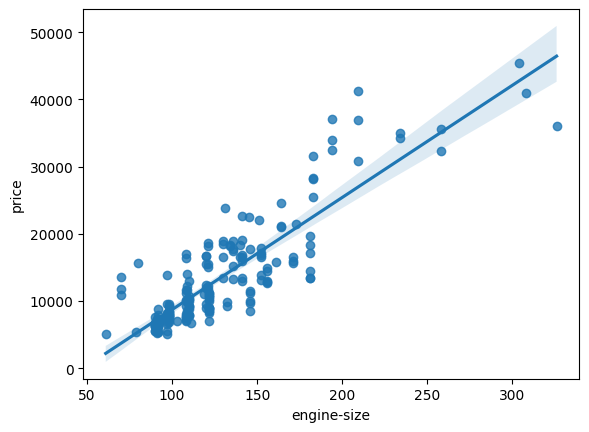

In [60]:
# engine-size vs price (positive relationship)
sns.regplot(x="engine-size", y="price", data=df)

In [61]:
df[['engine-size' ,'price']].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


<Axes: xlabel='highway-L/100km', ylabel='price'>

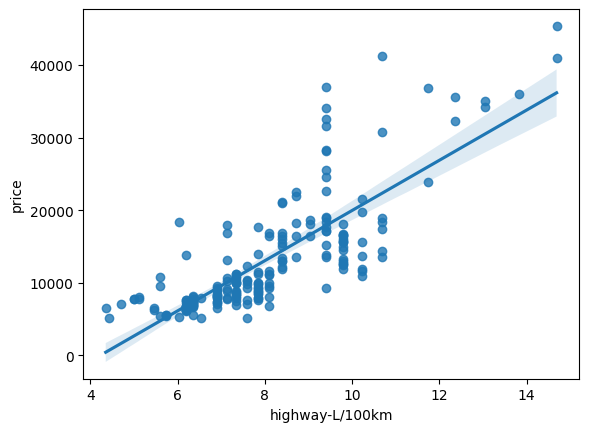

In [63]:
# highway-L/100km vs price (negative relationship)
sns.regplot(x="highway-L/100km", y="price", data=df)

In [64]:
df[['highway-L/100km','price']].corr()

,highway-L/100km,price
highway-L/100km,1.000000,0.801118
price,0.801118,1.000000


<Axes: xlabel='peak-rpm', ylabel='price'>

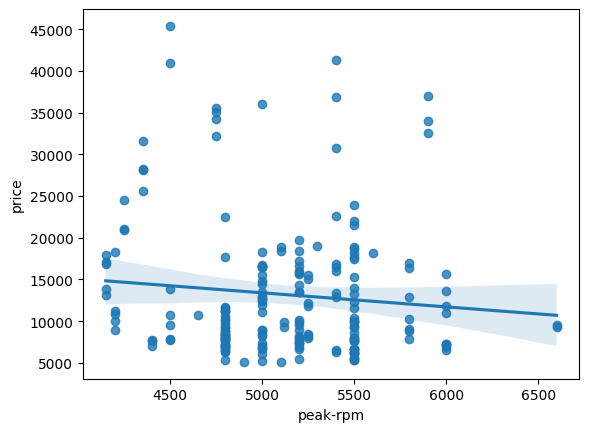

In [65]:
# peak-rpm vs price (not good predictor)
sns.regplot(x='peak-rpm' , y='price', data=df)

In [66]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101542
price,-0.101542,1.000000


<Axes: xlabel='stroke', ylabel='price'>

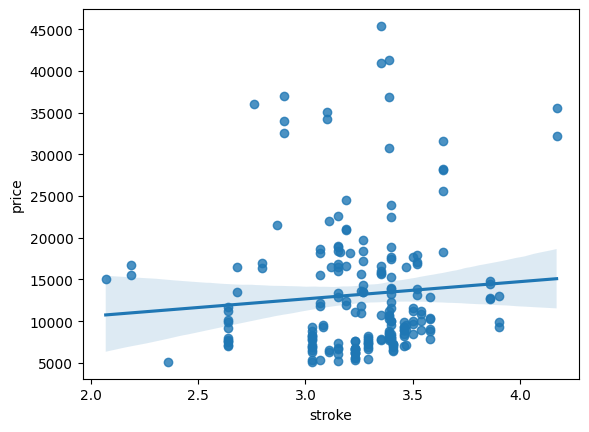

In [68]:
# stroke vs price (not good predictor)
sns.regplot(x='stroke' , y='price', data=df)

In [69]:
df[['stroke','price']].corr()

,stroke,price
stroke,1.000000,0.082267
price,0.082267,1.000000


In [70]:
# Categorical Columns

<Axes: xlabel='body-style', ylabel='price'>

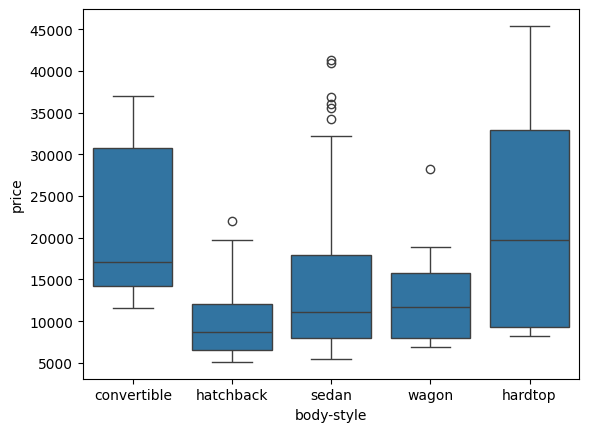

In [71]:
# body-style vs price (not be a good predictor of price)
sns.boxplot(x="body-style", y="price", data=df)

<Axes: xlabel='engine-location', ylabel='price'>

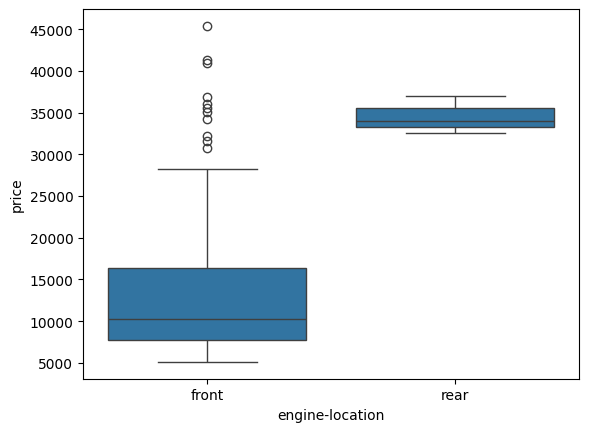

In [74]:
# engine-location vs price (good predictor)
sns.boxplot(x="engine-location", y="price", data=df)

<Axes: xlabel='drive-wheels', ylabel='price'>

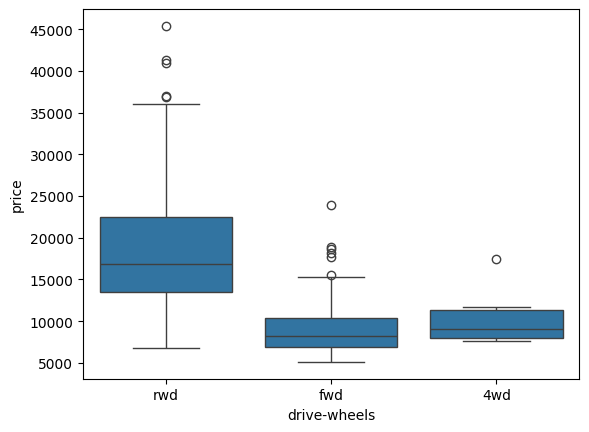

In [75]:
# drive-wheels vs price (not be a good predictor)
sns.boxplot(x="drive-wheels", y="price", data=df)

In [76]:
df['drive-wheels'].unique()

<StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str

In [87]:
group =  df[['drive-wheels','price']]
group1 = group.groupby(['drive-wheels'],as_index=False).mean()
group1

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


In [89]:
group1 = df[['drive-wheels','body-style','price']]
grouped = group1.groupby(['drive-wheels','body-style'],as_index=False).mean()
grouped.head()

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000


In [93]:
pivot = grouped.pivot(index='drive-wheels',columns='body-style')
pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [94]:
pivot= pivot.fillna(0)
pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

In [95]:
group3 = df[['body-style','price']]
grouped3 = group3.groupby(['body-style'],as_index= False).mean()
grouped3

,body-style,price
0,convertible,21890.500000
1,hardtop,22208.500000
2,hatchback,9957.441176
3,sedan,14459.755319
4,wagon,12371.960000


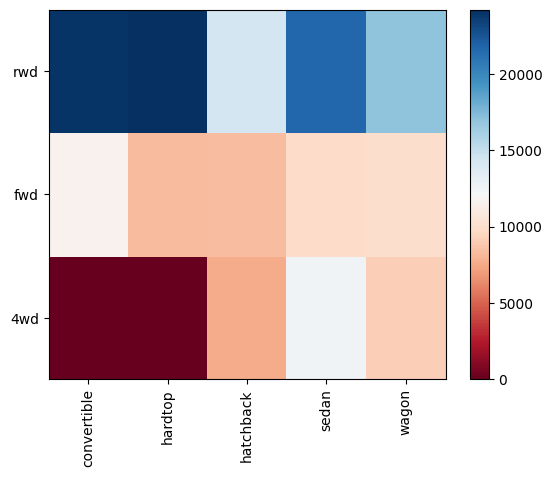

In [99]:
fig, ax = plt.subplots()
im = ax.pcolor(pivot, cmap='RdBu')

#label names
col_labels = pivot.columns.levels[1]
row_labels = pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(col_labels, minor=False)
ax.set_yticklabels(row_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

In [100]:
# CORRELATION AND CAUSION

In [108]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-L/100km',
       'highway-L/100km', 'price'],
      dtype='str')

In [101]:
from scipy import stats

In [114]:
Coefficient, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print("The Pearson Correlation Coefficient is",Coefficient , " with a P-value of P =", p_value)  

The Pearson Correlation Coefficient is 0.584641822265508  with a P-value of P = 8.076488270732847e-20


In [116]:
Coefficient, p_value = stats.pearsonr(df['horsepower'], df['price'])
print("The Pearson Correlation Coefficient is", Coefficient, " with a P-value of P =", p_value)  

The Pearson Correlation Coefficient is 0.8096811975632288  with a P-value of P = 6.058444649710043e-48


In [117]:
Coefficient, p_value = stats.pearsonr(df['length'], df['price'])
print("The Pearson Correlation Coefficient is", Coefficient, " with a P-value of P =", p_value)  

The Pearson Correlation Coefficient is 0.690628380448364  with a P-value of P = 8.016477466158899e-30


In [118]:
Coefficient, p_value = stats.pearsonr(df['width'], df['price'])
print("The Pearson Correlation Coefficient is", Coefficient, " with a P-value of P =", p_value)  

The Pearson Correlation Coefficient is 0.7512653440522674  with a P-value of P = 9.200335510481227e-38


In [119]:
Coefficient, p_value = stats.pearsonr(df['curb-weight'], df['price'])
print( "The Pearson Correlation Coefficient is", Coefficient, " with a P-value of P = ", p_value) 

The Pearson Correlation Coefficient is 0.8344145257702843  with a P-value of P =  2.189577238893924e-53


In [120]:
Coefficient, p_value = stats.pearsonr(df['engine-size'], df['price'])
print( "The Pearson Correlation Coefficient is", Coefficient, " with a P-value of P = ", p_value) 

The Pearson Correlation Coefficient is 0.8723351674455184  with a P-value of P =  9.26549162219869e-64


In [121]:
Coefficient, p_value = stats.pearsonr(df['bore'], df['price'])
print( "The Pearson Correlation Coefficient is", Coefficient, " with a P-value of P = ", p_value) 

The Pearson Correlation Coefficient is 0.5431537659807734  with a P-value of P =  8.051208825441017e-17


In [122]:
Coefficient, p_value = stats.pearsonr(df['city-L/100km'], df['price'])
print( "The Pearson Correlation Coefficient is", Coefficient, " with a P-value of P = ", p_value) 

The Pearson Correlation Coefficient is 0.7898975136626945  with a P-value of P =  3.9031064009395423e-44


In [123]:
Coefficient, p_value = stats.pearsonr(df['highway-L/100km'], df['price'])
print( "The Pearson Correlation Coefficient is", Coefficient, " with a P-value of P = ", p_value) 

The Pearson Correlation Coefficient is 0.8011176263981975  with a P-value of P =  3.04678458104143e-46
